In [1]:
import laspy
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [2]:
TRAIN_DIRS = [
    Path("../data/train/00"),
    Path("../data/train/10"),
    Path("../data/train/40"),
]
VAL_DIR   = Path("../data/val/04")
TEST_DIR  = Path("../data/test/04")

# Μετράμε αρχεία
for d in TRAIN_DIRS:
    print(f"train/{d.name}: {len(list(d.glob('*.laz')))} files")
print(f"val/{VAL_DIR.name}:  {len(list(VAL_DIR.glob('*.laz')))} files")
print(f"test/{TEST_DIR.name}: {len(list(TEST_DIR.glob('*.laz')))} files")

train/00: 1000 files
train/10: 1000 files
train/40: 1000 files
val/04:  1000 files
test/04: 1000 files


In [3]:
# Φόρτωσε ένα αρχείο από κάθε subset
for d in TRAIN_DIRS:
    f = sorted(d.glob("*.laz"))[0]
    las = laspy.read(str(f))
    print(f"\n=== train/{d.name} — {f.name} ===")
    print(f"Points: {len(las.points):,}")
    for dim in las.point_format.dimension_names:
        arr = np.array(getattr(las, dim), dtype=np.float64)
        print(f"  {dim:<25} min={arr.min():>12.3f}  max={arr.max():>12.3f}  mean={arr.mean():>12.3f}")


=== train/00 — TRAIN-0436_6432-003123986.laz ===
Points: 156,491
  X                         min=36250000.000  max=36300000.000  mean=36276651.534
  Y                         min=-568050000.000  max=-568000001.000  mean=-568025186.953
  Z                         min=    3635.000  max=   28407.000  mean=    9762.567
  intensity                 min=     412.000  max=   29744.000  mean=    2614.593
  return_number             min=       1.000  max=       5.000  mean=       1.357
  number_of_returns         min=       1.000  max=       5.000  mean=       1.714
  synthetic                 min=       0.000  max=       0.000  mean=       0.000
  key_point                 min=       0.000  max=       0.000  mean=       0.000
  withheld                  min=       0.000  max=       0.000  mean=       0.000
  overlap                   min=       0.000  max=       0.000  mean=       0.000
  scanner_channel           min=       0.000  max=       0.000  mean=       0.000
  scan_direction_flag     

In [4]:
CLASS_NAMES = {
    1: "Unclassified", 2: "Ground", 3: "Low Vegetation",
    4: "Medium Vegetation", 5: "High Vegetation", 6: "Building",
    9: "Water", 17: "Bridge", 64: "Perennial Snow"
}

splits = {
    "train/00": Path("../data/train/00"),
    "train/10": Path("../data/train/10"),
    "train/40": Path("../data/train/40"),
    "val/04":   Path("../data/val/04"),
    "test/04":  Path("../data/test/04"),
}

for split_name, split_dir in splits.items():
    all_files = sorted(split_dir.glob("*.laz"))
    total_counts = {}

    for f in all_files:
        las = laspy.read(str(f))
        cls, cnt = np.unique(np.array(las.classification), return_counts=True)
        for c, n in zip(cls, cnt):
            total_counts[int(c)] = total_counts.get(int(c), 0) + int(n)

    total = sum(total_counts.values())
    print(f"\n=== {split_name} ({len(all_files)} files, {total:,} points) ===")
    print(f"  {'Κλάση':<5} {'Όνομα':<20} {'Πλήθος':>12} {'%':>8}")
    print(f"  {'-'*48}")
    for c, n in sorted(total_counts.items()):
        name = CLASS_NAMES.get(c, f"cls_{c}")
        print(f"  {c:<5} {name:<20} {n:>12,} {100*n/total:>7.1f}%")


=== train/00 (1000 files, 91,309,139 points) ===
  Κλάση Όνομα                      Πλήθος        %
  ------------------------------------------------
  1     Unclassified              624,344     0.7%
  2     Ground                 35,989,279    39.4%
  3     Low Vegetation          3,797,488     4.2%
  4     Medium Vegetation       4,048,672     4.4%
  5     High Vegetation        43,816,519    48.0%
  6     Building                2,610,733     2.9%
  9     Water                     308,863     0.3%
  17    Bridge                     83,176     0.1%
  64    Perennial Snow             23,416     0.0%
  65    cls_65                      3,538     0.0%
  66    cls_66                      3,111     0.0%

=== train/10 (1000 files, 91,349,332 points) ===
  Κλάση Όνομα                      Πλήθος        %
  ------------------------------------------------
  1     Unclassified              477,500     0.5%
  2     Ground                 35,223,427    38.6%
  3     Low Vegetation          4

In [5]:
# Κλάσεις που κρατάμε
VALID_CLASSES = {2, 3, 4, 5, 6, 9, 17, 64}

# Δείχνουμε τι πετάμε και τι κρατάμε
DISCARD = {1: "Unclassified", 65: "cls_65", 66: "cls_66"}

print("Πετάμε:")
for c, name in DISCARD.items():
    print(f"  {c} — {name}")

print("\nΚρατάμε:")
for c in sorted(VALID_CLASSES):
    print(f"  {c} — {CLASS_NAMES[c]}")

# Επαλήθευση σε ένα αρχείο
f = sorted(Path("../data/train/00").glob("*.laz"))[0]
las = laspy.read(str(f))
labels = np.array(las.classification)

mask = np.isin(labels, list(VALID_CLASSES))
print(f"\nΣample αρχείο: {f.name}")
print(f"  Πριν:  {len(labels):,} points")
print(f"  Μετά:  {mask.sum():,} points")
print(f"  Πεταμένα: {(~mask).sum():,} points ({100*(~mask).sum()/len(labels):.2f}%)")

Πετάμε:
  1 — Unclassified
  65 — cls_65
  66 — cls_66

Κρατάμε:
  2 — Ground
  3 — Low Vegetation
  4 — Medium Vegetation
  5 — High Vegetation
  6 — Building
  9 — Water
  17 — Bridge
  64 — Perennial Snow

Σample αρχείο: TRAIN-0436_6432-003123986.laz
  Πριν:  156,491 points
  Μετά:  155,746 points
  Πεταμένα: 745 points (0.48%)


In [6]:
DROP_DIMS = [
    "synthetic", "key_point", "withheld", "overlap",
    "scanner_channel", "scan_direction_flag", "edge_of_flight_line",
    "user_data", "gps_time", "point_source_id"
]

KEEP_DIMS = [dim for dim in las.point_format.dimension_names if dim not in DROP_DIMS]

print("Πετάμε:")
for d in DROP_DIMS:
    print(f"  - {d}")

print(f"\nΚρατάμε:")
for d in KEEP_DIMS:
    print(f"  - {d}")

Πετάμε:
  - synthetic
  - key_point
  - withheld
  - overlap
  - scanner_channel
  - scan_direction_flag
  - edge_of_flight_line
  - user_data
  - gps_time
  - point_source_id

Κρατάμε:
  - X
  - Y
  - Z
  - intensity
  - return_number
  - number_of_returns
  - classification
  - scan_angle
  - red
  - green
  - blue
  - nir


In [7]:
FEATURE_DIMS = ["X", "Y", "Z", "intensity", "return_number", 
                "number_of_returns", "scan_angle", "red", "green", "blue", "nir"]
LABEL_DIM = "classification"

print(f"Features (X): {len(FEATURE_DIMS)}")
for f in FEATURE_DIMS:
    print(f"  - {f}")
print(f"\nLabel (y): {LABEL_DIM}")

Features (X): 11
  - X
  - Y
  - Z
  - intensity
  - return_number
  - number_of_returns
  - scan_angle
  - red
  - green
  - blue
  - nir

Label (y): classification


In [8]:
problems = []

for split_name, split_dir in splits.items():
    corrupt = 0
    rgb_zero = 0
    total = 0

    for f in sorted(split_dir.glob("*.laz")):
        las = laspy.read(str(f))
        mask = np.isin(np.array(las.classification), list(VALID_CLASSES))
        total += mask.sum()

        rn = np.array(las.return_number)[mask]
        nr = np.array(las.number_of_returns)[mask]
        r  = np.array(las.red)[mask]
        g  = np.array(las.green)[mask]
        b  = np.array(las.blue)[mask]

        corrupt  += int(((rn == 0) | (nr == 0)).sum())
        rgb_zero += int(((r == 0) & (g == 0) & (b == 0)).sum())

    print(f"\n{split_name} ({total:,} pts)")
    print(f"  Corrupt (return=0):     {corrupt:>10,}  ({100*corrupt/total:.3f}%)")
    print(f"  RGB ολικό μηδέν:        {rgb_zero:>10,}  ({100*rgb_zero/total:.3f}%)")


train/00 (90,678,146 pts)
  Corrupt (return=0):              0  (0.000%)
  RGB ολικό μηδέν:            19,757  (0.022%)

train/10 (90,864,095 pts)
  Corrupt (return=0):              0  (0.000%)
  RGB ολικό μηδέν:            18,629  (0.021%)

train/40 (90,827,400 pts)
  Corrupt (return=0):              0  (0.000%)
  RGB ολικό μηδέν:            18,651  (0.021%)

val/04 (91,283,996 pts)
  Corrupt (return=0):              0  (0.000%)
  RGB ολικό μηδέν:            21,179  (0.023%)

test/04 (96,038,406 pts)
  Corrupt (return=0):              0  (0.000%)
  RGB ολικό μηδέν:            18,643  (0.019%)


το LAS format δεν επιτρέπει missing values δομικά. Κάθε point έχει υποχρεωτικά τιμή σε κάθε field. Αν ένα field δεν έχει μετρηθεί, αποθηκεύεται ως 0

In [9]:
FEATURE_DIMS = ["x", "y", "z", "intensity", "return_number", 
                "number_of_returns", "scan_angle"]

print("Τελικά features:")
for f in FEATURE_DIMS:
    print(f"  - {f}")
print(f"\nΣύνολο: {len(FEATURE_DIMS)} features")
print(f"Label:  classification")

Τελικά features:
  - x
  - y
  - z
  - intensity
  - return_number
  - number_of_returns
  - scan_angle

Σύνολο: 7 features
Label:  classification


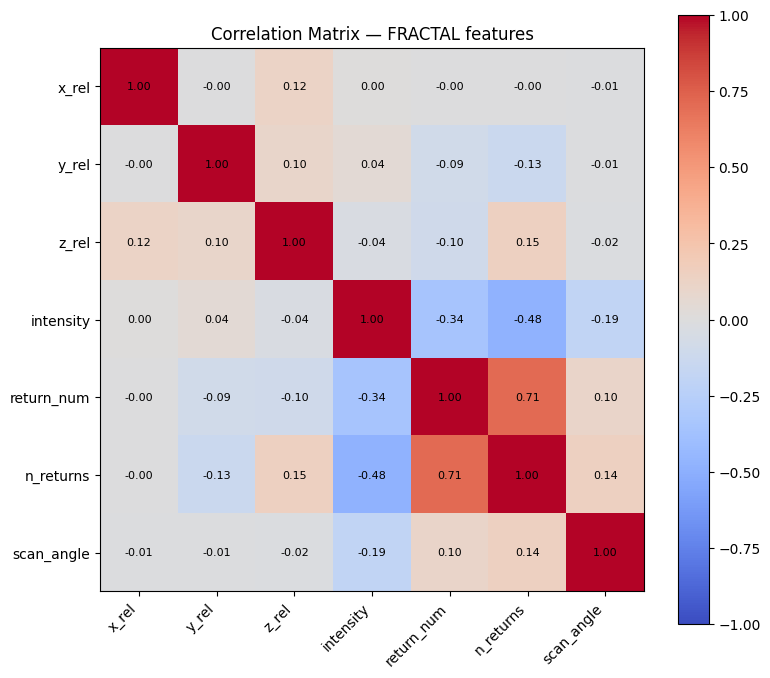

In [10]:
from pathlib import Path

# Μαζεύουμε data από 5 τυχαία αρχεία
np.random.seed(42)
sample_files = np.random.choice(sorted(Path("../data/train/00").glob("*.laz")), 5, replace=False)

X_list, y_list = [], []
for f in sample_files:
    las = laspy.read(str(f))
    mask = np.isin(np.array(las.classification), list(VALID_CLASSES))
    
    x = np.array(las.x)[mask]; y = np.array(las.y)[mask]; z = np.array(las.z)[mask]
    
    X_list.append(np.column_stack([
        x - x.mean(), y - y.mean(), z - z.mean(),
        np.array(las.intensity)[mask],
        np.array(las.return_number)[mask],
        np.array(las.number_of_returns)[mask],
        np.array(las.scan_angle)[mask],
    ]))
    y_list.append(np.array(las.classification)[mask])

X = np.vstack(X_list)
y = np.concatenate(y_list)

NAMES = ["x_rel", "y_rel", "z_rel", "intensity", "return_num", "n_returns", "scan_angle"]

# Correlation matrix
corr = np.corrcoef(X.T)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(NAMES))); ax.set_xticklabels(NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(NAMES))); ax.set_yticklabels(NAMES)
for i in range(len(NAMES)):
    for j in range(len(NAMES)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
plt.title("Correlation Matrix — FRACTAL features")
plt.tight_layout()
plt.show()

Ερμηνεία Correlation Matrix
Υψηλή συσχέτιση (προβληματική):

return_num ↔ n_returns = 0.71 — αναμενόμενο, αλλά όχι redundant. Το return_num λέει "ποστή ανάκλαση είσαι" και το n_returns "πόσες συνολικά υπάρχουν". Κρατάμε και τα δύο.

Μέτριες συσχετίσεις (ενδιαφέρουσες):

intensity ↔ return_num = -0.34 — οι πρώτες ανακλάσεις (return_num=1) έχουν υψηλότερο intensity. Φυσικό.
intensity ↔ n_returns = -0.48 — points με πολλές ανακλάσεις (βλάστηση) έχουν χαμηλότερο intensity. Φυσικό.

Χαμηλές συσχετίσεις (καλό σημάδι):

x_rel, y_rel με όλα ~0.00 — οι θέσεις δεν συσχετίζονται με τα άλλα features. 
scan_angle με όλα <0.20 — ανεξάρτητο feature. 
z_rel με όλα <0.15 — σχετικά ανεξάρτητο. 

Συμπέρασμα: κανένα feature δεν είναι redundant. Κρατάμε και τα 7.

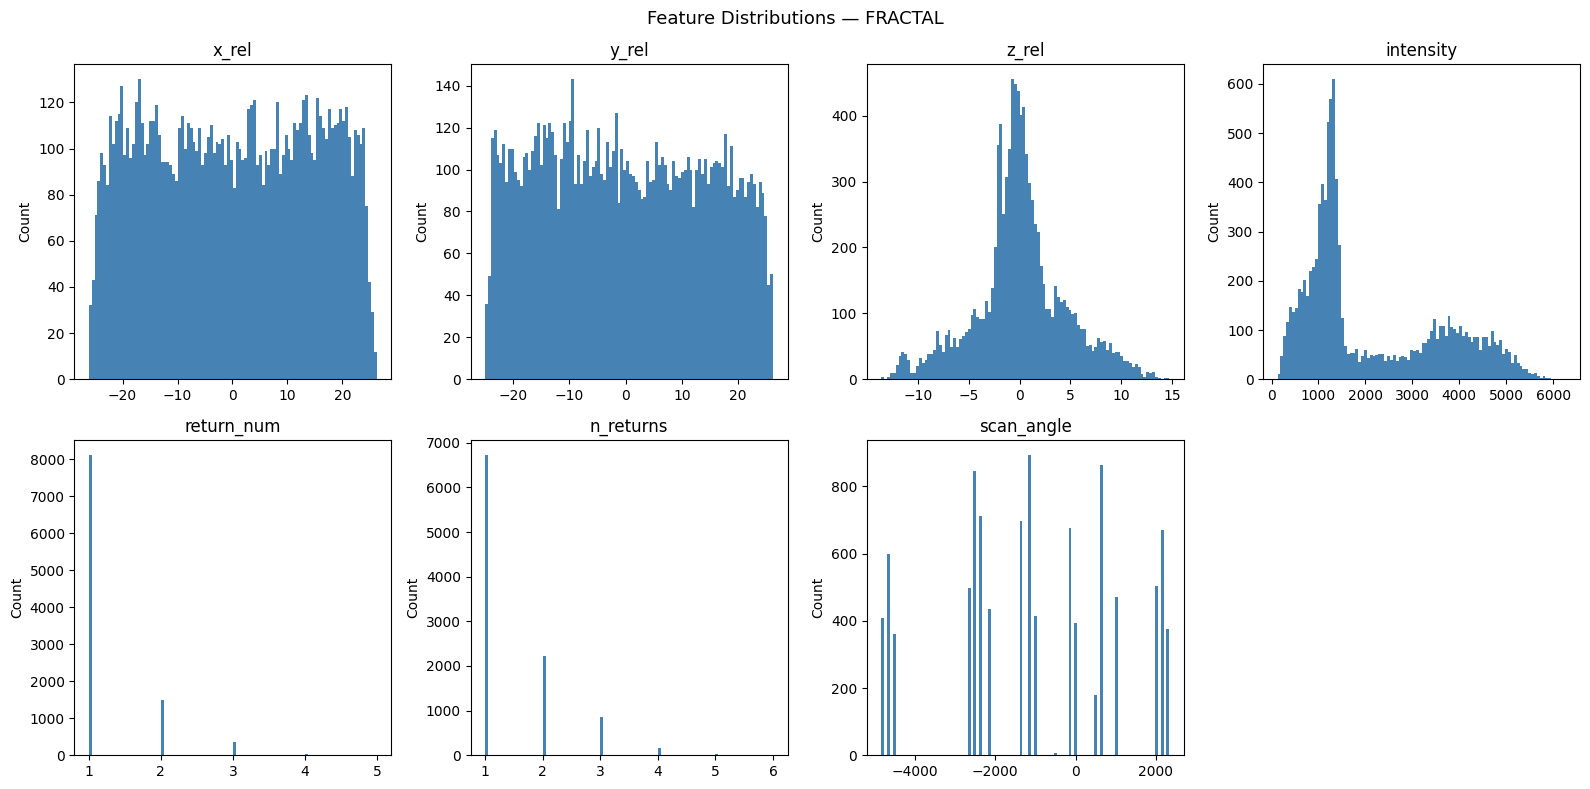

In [17]:
# Subsample για γρήγορο plot
idx = np.random.choice(len(X), 10000, replace=False)
X_s = X[idx]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, name in enumerate(NAMES):
    axes[i].hist(X_s[:, i], bins=100, color="steelblue", edgecolor="none")
    axes[i].set_title(name)
    axes[i].set_ylabel("Count")

axes[-1].axis("off")
plt.suptitle("Feature Distributions — FRACTAL", fontsize=13)
plt.tight_layout()
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler
import json

scaler_z   = StandardScaler()
scaler_int = StandardScaler()
scaler_x   = StandardScaler()
scaler_y   = StandardScaler()

for f in sorted(f for d in TRAIN_DIRS for f in d.glob("*.laz")):
    las = laspy.read(str(f))
    mask = np.isin(np.array(las.classification), list(VALID_CLASSES))
    
    x = np.array(las.x)[mask]; y = np.array(las.y)[mask]; z = np.array(las.z)[mask]
    
    scaler_x.partial_fit((x - x.mean()).reshape(-1, 1))
    scaler_y.partial_fit((y - y.mean()).reshape(-1, 1))
    scaler_z.partial_fit((z - z.mean()).reshape(-1, 1))
    scaler_int.partial_fit(np.array(las.intensity)[mask].reshape(-1, 1))

stats = {
    "x_rel":     {"mean": float(scaler_x.mean_[0]),   "std": float(scaler_x.scale_[0])},
    "y_rel":     {"mean": float(scaler_y.mean_[0]),   "std": float(scaler_y.scale_[0])},
    "z_rel":     {"mean": float(scaler_z.mean_[0]),   "std": float(scaler_z.scale_[0])},
    "intensity": {"mean": float(scaler_int.mean_[0]), "std": float(scaler_int.scale_[0])},
}

with open("../outputs/normalizer_stats.json", "w") as f:
    json.dump(stats, f, indent=2)

print("Stats από ΟΛΑ τα train αρχεία:")
for feat, s in stats.items():
    print(f"  {feat:<12} mean={s['mean']:>10.3f}  std={s['std']:>10.3f}")

Stats από ΟΛΑ τα train αρχεία:
  x_rel        mean=     0.000  std=    14.382
  y_rel        mean=    -0.000  std=    14.370
  z_rel        mean=    -0.000  std=     6.681
  intensity    mean=  7340.857  std= 14285.285


Feature          Mean      Std      Min      Max
--------------------------------------------
x_rel          -0.000    0.984   -1.857    1.619
y_rel           0.000    0.991   -1.723    1.757
z_rel          -0.000    0.902   -0.920    2.787
intensity      -0.331    0.098   -0.485   -0.012
return_num      0.226    0.110    0.167    0.833
n_returns       0.286    0.152    0.167    0.833
scan_angle     -0.218    0.069   -0.300   -0.117


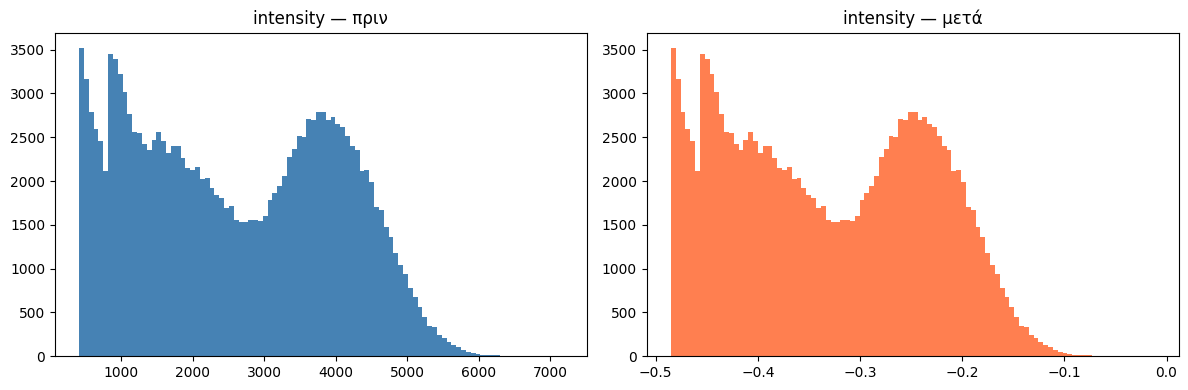

In [20]:
import json

with open("../outputs/normalizer_stats.json") as f:
    stats = json.load(f)

def normalize(x_rel, y_rel, z_rel, intensity, return_num, n_returns, scan_angle, is_fractal=True):
    out = np.zeros((len(x_rel), 7), dtype=np.float32)
    out[:, 0] = (x_rel     - stats["x_rel"]["mean"])     / stats["x_rel"]["std"]
    out[:, 1] = (y_rel     - stats["y_rel"]["mean"])     / stats["y_rel"]["std"]
    out[:, 2] = (z_rel     - stats["z_rel"]["mean"])     / stats["z_rel"]["std"]
    out[:, 3] = (intensity - stats["intensity"]["mean"]) / stats["intensity"]["std"]
    out[:, 4] = return_num / 6.0
    out[:, 5] = n_returns  / 6.0
    if is_fractal:
        out[:, 6] = scan_angle * 0.006 / 60.0  # LAS 1.4 → μοίρες → /60
    else:
        out[:, 6] = scan_angle / 60.0           # YellowScan ήδη μοίρες
    return out

# Test σε ένα αρχείο
las = laspy.read(str(sorted(Path("../data/train/00").glob("*.laz"))[0]))
mask = np.isin(np.array(las.classification), list(VALID_CLASSES))
x = np.array(las.x)[mask]; yc = np.array(las.y)[mask]; z = np.array(las.z)[mask]

X_norm = normalize(
    x - x.mean(), yc - yc.mean(), z - z.mean(),
    np.array(las.intensity)[mask],
    np.array(las.return_number)[mask],
    np.array(las.number_of_returns)[mask],
    np.array(las.scan_angle)[mask],
    is_fractal=True
)

NAMES = ["x_rel", "y_rel", "z_rel", "intensity", "return_num", "n_returns", "scan_angle"]
print(f"{'Feature':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 44)
for i, name in enumerate(NAMES):
    print(f"{name:<12} {X_norm[:,i].mean():>8.3f} {X_norm[:,i].std():>8.3f} {X_norm[:,i].min():>8.3f} {X_norm[:,i].max():>8.3f}")

# Plot πριν/μετά για intensity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(np.array(las.intensity)[mask], bins=100, color="steelblue")
axes[0].set_title("intensity — πριν")
axes[1].hist(X_norm[:, 3], bins=100, color="coral")
axes[1].set_title("intensity — μετά")
plt.tight_layout()
plt.show()